In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from entropy_branching import EntropyBranchingConfig, entropy_branch_generate
from multibeam_search import plot_discrete_branch_graph

In [2]:
model_id = "Qwen/Qwen3.5-27B-FP8"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_id)

branching_config = EntropyBranchingConfig(
    max_live_branches=4,
    split_width=2,
    real_choice_trigger=True,
    choice_min_thought_tokens=12,
    choice_top1_max_prob=0.60,
    choice_top2_min_prob=0.15,
    choice_max_margin=0.20,
    choice_entropy_floor=1.0,
    choice_window=32,
    choice_percentile=0.85,
    entropy_threshold=2.5,
    entropy_floor=1.5,
    adaptive_trigger=False,
    adaptive_min_thought_tokens=12,
    adaptive_window=32,
    adaptive_z=1.0,
    max_splits_per_branch=3,
    split_cooldown_tokens=2,
    temperature=0.8,
    top_p=0.98,
    max_new_tokens=256,
    num_return_sequences=2,
    length_penalty_alpha=0.7,
    seed=7
)

AttributeError: 'Qwen3_5Config' object has no attribute 'vocab_size'

In [ ]:
messages = [
    {
        "role": "system",
        "content": "You are a helpful medical assistant. After thinking, answer each question with just the corresponding option's single letter",
    },
    {
        "role": "user",
        "content": """In pediatric patients, which of the following complications has been documented to occur in association with lateral condyle fracture nonunion?

Options:
A. Lateral elbow pain
B. Progressive cubitus valgus
C. Elbow instability
D. Growth plate arrest
E. Cubitus varus
F. Radial nerve palsy
G. Median nerve entrapment
H. Posterolateral rotatory instability
I. Radial nerve compression
J. Ulnar nerve palsy""",
    },
]

model_inputs = tokenizer.apply_chat_template(
    messages,
    return_tensors="pt",
    return_dict=True,
    add_generation_prompt=True,
).to(device)

result = entropy_branch_generate(
    model=model,
    tokenizer=tokenizer,
    input_ids=model_inputs["input_ids"],
    attention_mask=model_inputs.get("attention_mask"),
    config=branching_config
)

branches_to_show = result.best_branches or result.completed_branches or result.live_branches
if not branches_to_show:
    raise RuntimeError("No branches were returned by entropy_branch_generate.")


In [ ]:
def format_optional_float(value):
    if value is None:
        return "n/a"
    return f"{value:.4f}"


def format_optional_int(value):
    if value is None:
        return "n/a"
    return str(value)


print(
    f"completed={len(result.completed_branches)} "
    f"live={len(result.live_branches)} "
    f"pruned={len(result.pruned_branches)} "
    f"split_nodes={len(result.split_branches)}"
)

for branch in branches_to_show:
    peak_choice_score = max(branch.choice_score_trace) if branch.choice_score_trace else None
    highest_threshold = max(
        (threshold for threshold in branch.adaptive_threshold_trace if threshold is not None),
        default=None,
    )
    first_trigger_step = branch.trigger_step_indices[0] if branch.trigger_step_indices else None
    best_top2_prob = max(branch.top2_prob_trace) if branch.top2_prob_trace else None
    lowest_margin = min(branch.top_margin_trace) if branch.top_margin_trace else None
    print(
        f"branch_id={branch.branch_id} "
        f"parent_id={branch.parent_id} "
        f"score={branch.normalized_score:.4f} "
        f"splits={branch.split_count} "
        f"reason={branch.finish_reason} "
        f"peak_choice_score={format_optional_float(peak_choice_score)} "
        f"first_trigger_step={format_optional_int(first_trigger_step)} "
        f"highest_trigger_threshold={format_optional_float(highest_threshold)} "
        f"best_top2_prob={format_optional_float(best_top2_prob)} "
        f"lowest_margin={format_optional_float(lowest_margin)}"
    )
    print(tokenizer.decode(result.prompt_ids + branch.generated_ids, skip_special_tokens=False))
    print("-" * 80)

print("lineage:", result.lineage)
if not result.split_branches:
    branch = branches_to_show[0]
    peak_choice_score = max(branch.choice_score_trace) if branch.choice_score_trace else None
    highest_threshold = max(
        (threshold for threshold in branch.adaptive_threshold_trace if threshold is not None),
        default=None,
    )
    best_top2_prob = max(branch.top2_prob_trace) if branch.top2_prob_trace else None
    lowest_margin = min(branch.top_margin_trace) if branch.top_margin_trace else None
    print(
        "no choice-point split fired: "
        f"peak_choice_score={format_optional_float(peak_choice_score)} "
        f"highest_trigger_threshold={format_optional_float(highest_threshold)} "
        f"best_top2_prob={format_optional_float(best_top2_prob)} "
        f"lowest_margin={format_optional_float(lowest_margin)}"
    )


In [ ]:
plot_discrete_branch_graph(result, tokenizer)

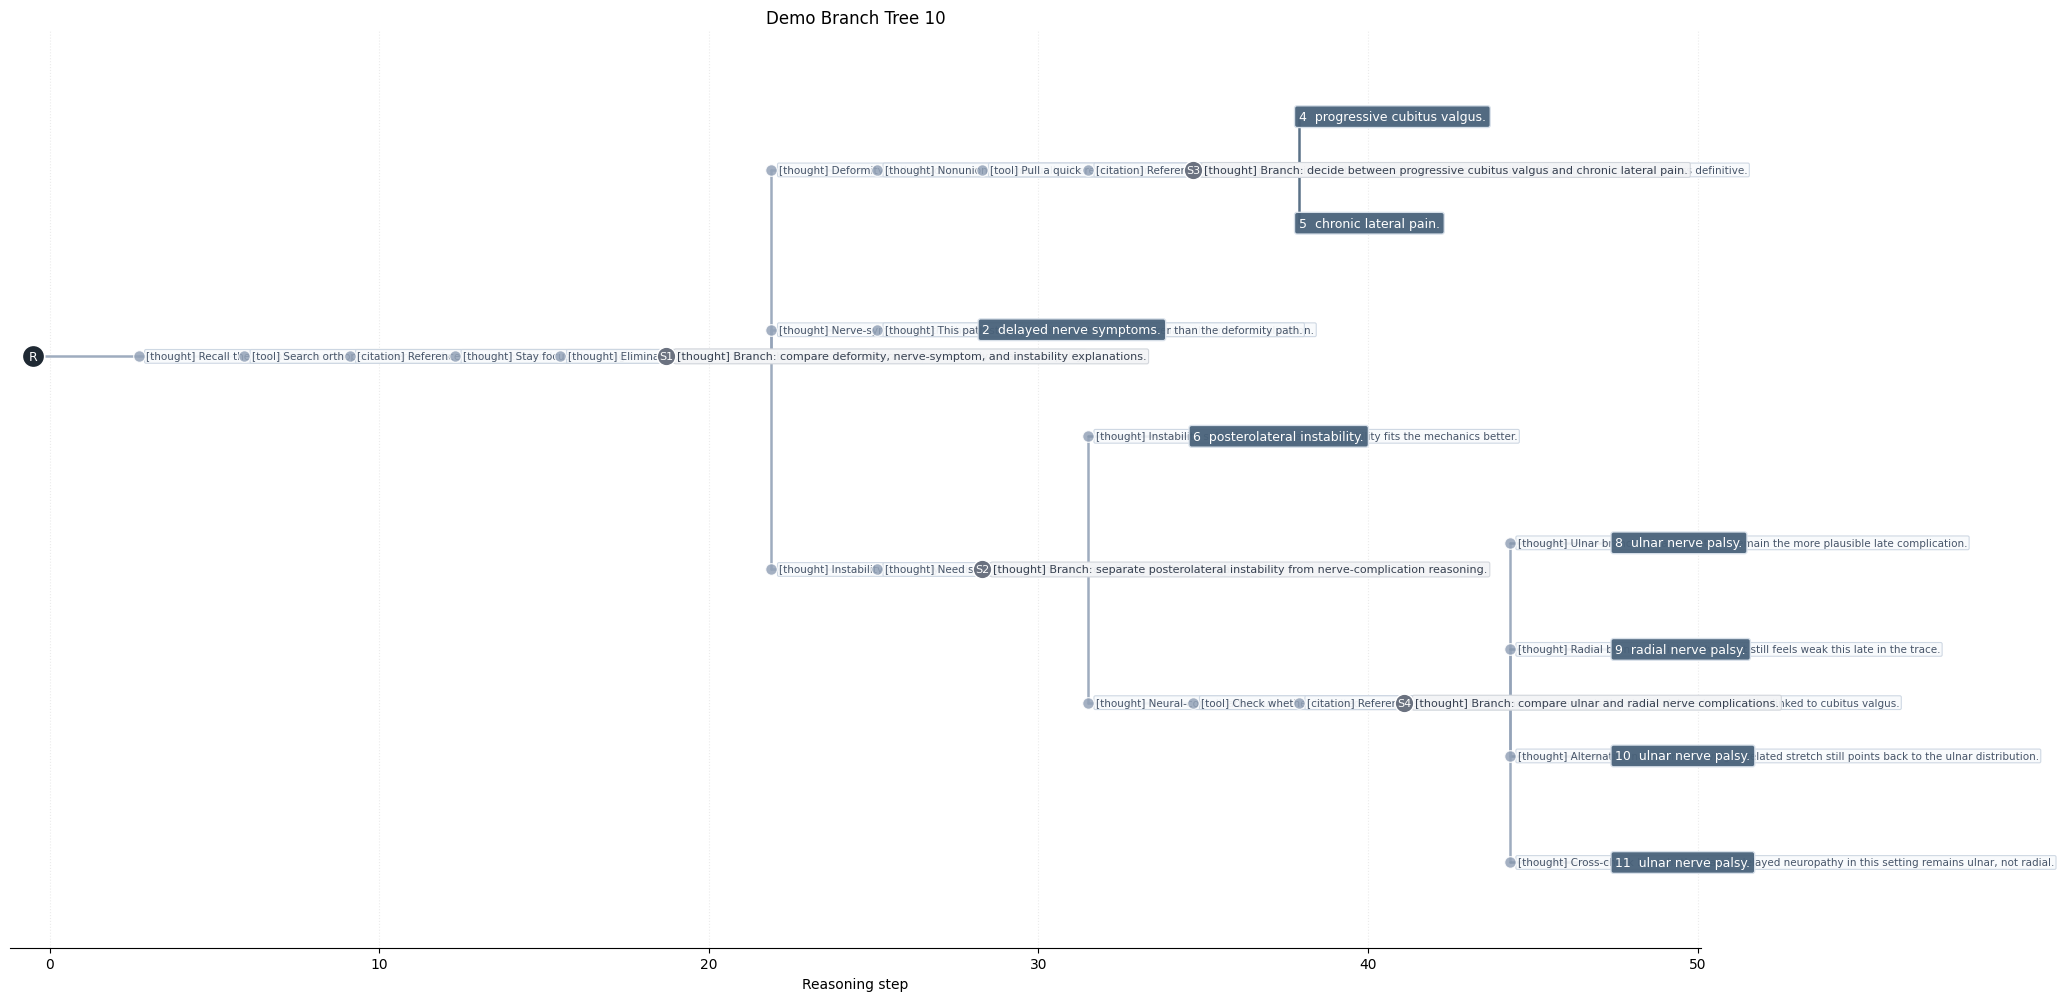

<Axes: title={'center': 'Demo Branch Tree 10'}, xlabel='Reasoning step'>

In [ ]:
from pathlib import Path
from multibeam_search import plot_branch_graph_json

plot_branch_graph_json(
    Path('demo_branch_tree_10.json'),
    save_path=None,
)